## 1 - Set Project Path


In [8]:
PROJECT_PATH = "/Users/manish/Documents/Semister 2/7. Project/Aarti Data Droplet"

## 2 - Import Libraries

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random
import os
from PIL import Image
import matplotlib.gridspec as gridspec

## 3 - Load Processed Dataset

In [ ]:
#Load saved dataset
images = np.load(os.path.join(PROJECT_PATH, "images.npy"))
labels = np.load(os.path.join(PROJECT_PATH, "labels.npy"))

#Print dataset shapes
print(images.shape)
print(labels.shape)

(54305, 224, 224, 3)
(54305,)


## 4 - Leaf Region Detection

**This is the core fix.**

PlantVillage images have a leaf centred in the frame with a plain or dark background.
We detect the green leaf area using HSV colour thresholding, then restrict all
droplet placement to pixels that are **confirmed to be on the leaf**.

> Without this step, random placement hits the background ~44% of the time —
> which is exactly what caused your droplets to appear outside the leaf.

In [ ]:
#Function to detect leaf area
def get_leaf_mask(image_rgb):

    #Convert RGB image to HSV format
    hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)

    #Define leaf color range
    lower_leaf = np.array([20, 20, 20])
    upper_leaf = np.array([100, 255, 255])

    #Create mask for leaf pixels
    mask = cv2.inRange(hsv, lower_leaf, upper_leaf)

    #Fill small gaps inside the leaf
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    #Slightly expand leaf region
    kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.dilate(mask, kernel_small, iterations=1)
    
    #Get leaf pixel coordinates
    ys, xs = np.where(mask > 0)

    return mask, ys, xs
print("Leaf mask function ready")

Leaf mask function ready


The leaf region was detected using HSV color thresholding and morphological operations. The resulting mask was used to restrict synthetic water droplet placement only to valid leaf pixels, preventing droplets from appearing on the background.

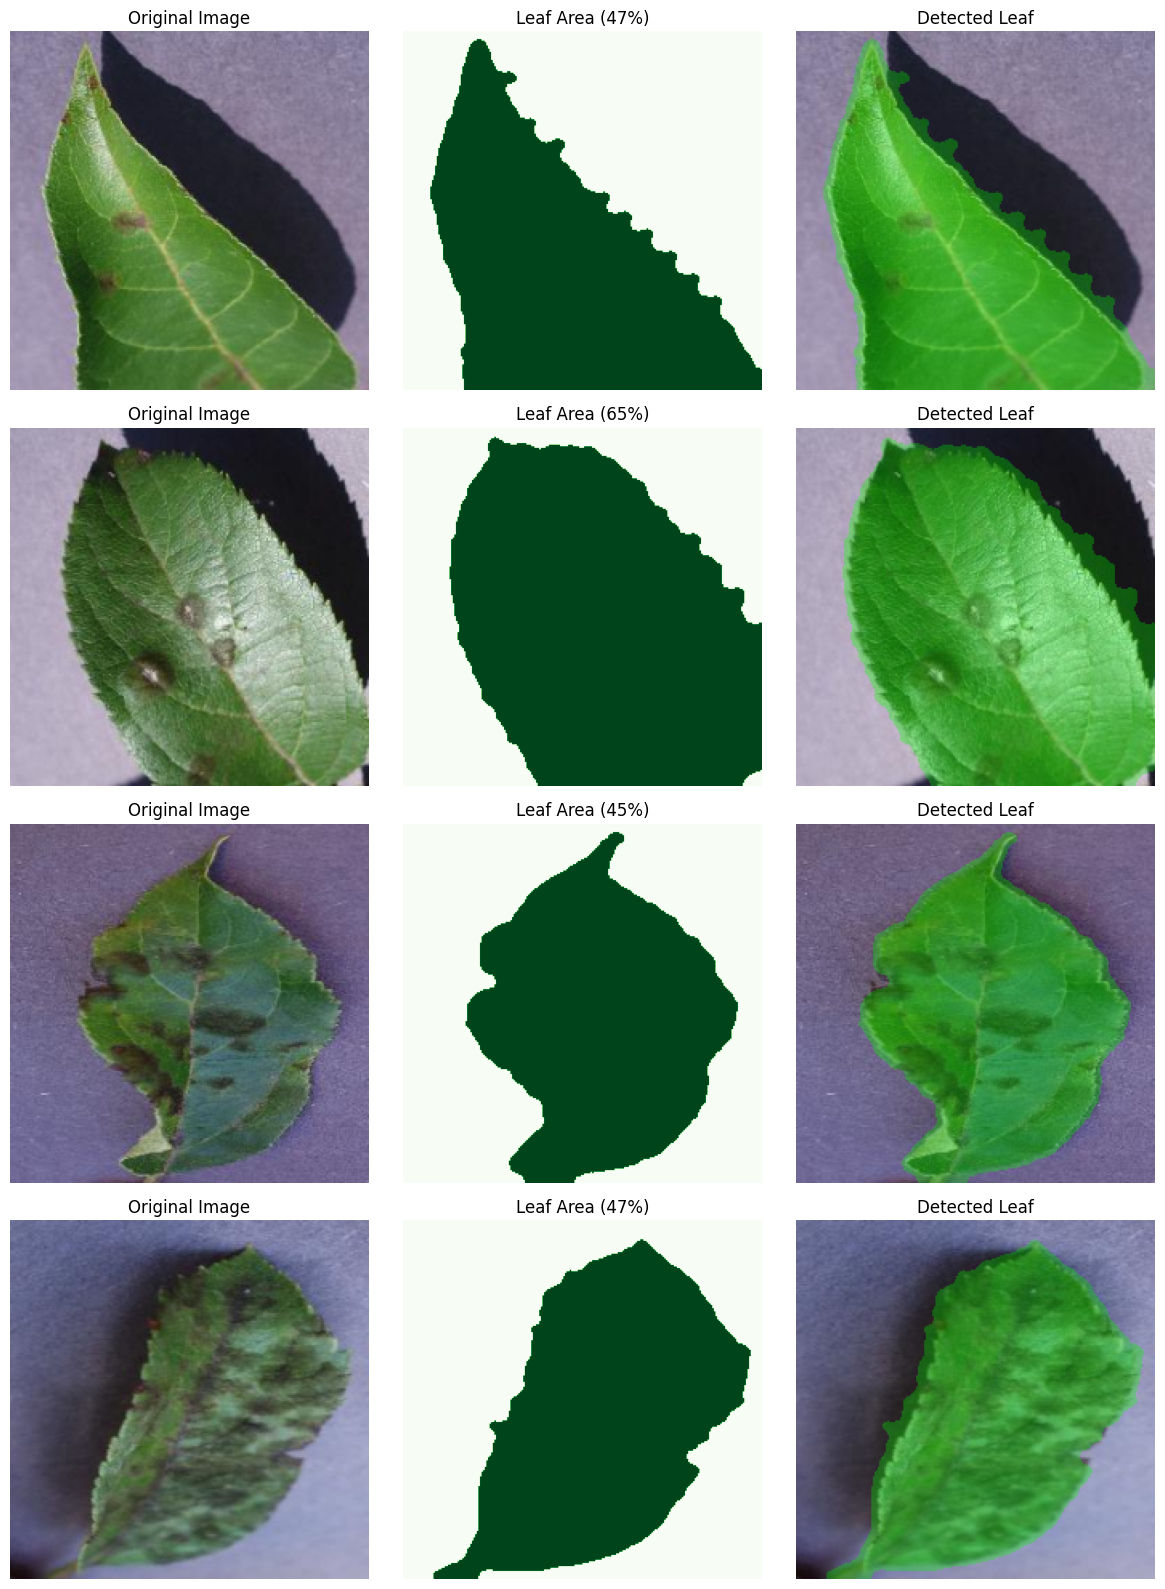

In [ ]:
#Check leaf detection on first 4 images
fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for i in range(4):
    #Select image
    image = images[i]

    #Get leaf mask
    leaf_mask, ys, xs = get_leaf_mask(image)

    #Calculate leaf coverage percentage
    coverage = (len(xs) / (image.shape[0] * image.shape[1])) * 100

    #Create overlay image
    overlay = image.copy()

    #Highlight detected leaf area in green
    overlay[leaf_mask > 0] = (overlay[leaf_mask > 0] * 0.7 + np.array([0, 255, 0]) * 0.3).astype(np.uint8)

    #Original image
    axes[i, 0].imshow(image)
    axes[i, 0].set_title("Original Image")
    axes[i, 0].axis("off")

    #Leaf mask
    axes[i, 1].imshow(leaf_mask, cmap="Greens")
    axes[i, 1].set_title(f"Leaf Area ({coverage:.0f}%)")
    axes[i, 1].axis("off")

    #Overlay image
    axes[i, 2].imshow(overlay)
    axes[i, 2].set_title("Detected Leaf")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

This step visually validates the leaf detection process by displaying the original image, generated leaf mask, and highlighted leaf region to ensure that synthetic water droplets will be placed only on the detected leaf area.

## 5 - Realistic Droplet Rendering



this code creates different water droplet shapes instead of using only circles.

Using multiple shapes makes droplets look more realistic because real water droplets are not always perfectly circular.


In [ ]:
#Create circular droplet
def circle_mask(cx, cy, radius, h, w):
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(mask,(cx, cy),radius,255, -1)
    return mask


#Create egg-shaped droplet
def egg_mask(cx, cy, radius, tilt, h, w):
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(mask, (cx, cy), radius, 255, -1)

    #Stretch lower part
    height = int(radius * 1.4)

    cv2.ellipse(mask, (cx, cy), (radius, height), tilt, 0, 180, 255, -1)

    return mask


#Calculate Bezier curve point
def bezier_point(p0, p1, p2, p3, t):

    x = ((1-t)**3 * p0[0] +
        3*(1-t)**2*t * p1[0] +
        3*(1-t)*t**2 * p2[0] +
        t**3 * p3[0])

    y = ((1-t)**3 * p0[1] +
        3*(1-t)**2*t * p1[1] +
        3*(1-t)*t**2 * p2[1] +
        t**3 * p3[1])

    return x, y


#Create irregular droplet
def bezier_mask(cx, cy, radius, h, w):
    mask = np.zeros((h, w), dtype=np.uint8)
    r = radius
    left_curve = [(cx, cy-r),
        (cx-r*2, cy-r//2),
        (cx-r*2, cy+r//2),
        (cx, cy+r)]

    right_curve = [(cx, cy+r),
        (cx+r*2, cy+r//2),
        (cx+r*2, cy-r//2),
        (cx, cy-r)]

    points = []

    for t in np.linspace(0, 1, 60):
        points.append(bezier_point(*left_curve, t))

    for t in np.linspace(0, 1, 60):
        points.append( bezier_point(*right_curve, t))

    polygon = np.array(points, dtype=np.int32).reshape((-1,1,2))

    cv2.fillPoly(mask, [polygon], 255)

    return mask

#Select droplet shape
def get_drop_shape_mask(cx, cy, radius, shape, tilt, h, w):

    if shape == 0:
        return circle_mask(cx, cy, radius, h, w)
    elif shape == 1:
        return egg_mask(cx, cy, radius, tilt, h, w)
    else:
        return bezier_mask(cx, cy, radius, h, w)

print("Shape functions loaded")

Shape functions loaded


Multiple droplet shapes (circular, egg-shaped, and Bézier-based irregular droplets) were generated to simulate the natural variation observed in real water droplets and improve the realism of synthetic environmental distortion.

In [ ]:
#Function to render one realistic water droplet
def render_single_droplet(image_rgb, cx, cy, radius, alpha=0.72, blur_k=9, shape=0, tilt=0):      #(earlier alpha=0.55, blur_k=15)
    # Get image size
    h, w = image_rgb.shape[:2]

    #Create copy of image
    result = image_rgb.copy().astype(np.float32)

    #Create droplet shape mask
    mask = get_drop_shape_mask(cx, cy, radius, shape, tilt, h, w)

    #Create lens distortion effect
    ys, xs = np.mgrid[0:h, 0:w].astype(np.float32)

    dx = (xs - cx) / (radius + 1e-6)
    dy = (ys - cy) / (radius + 1e-6)

    dist = np.sqrt(dx**2 + dy**2)

    inside = (mask > 0).astype(np.float32)

    strength = 0.8                                                          #(earlier 0.5)
    warp = inside * strength * (dist**1.8)                                  #(earlier - only dist)

    src_x = np.clip(
        xs - warp * dx * radius * 0.45, 0, w - 1                            #(earlier 0.35)  
    ).astype(np.float32)

    src_y = np.clip(
        ys - warp * dy * radius * 0.45, 0, h - 1                             #(earlier 0.35) 
    ).astype(np.float32)

    #Apply distortion
    img_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    distorted = cv2.remap(img_bgr, src_x, src_y, cv2.INTER_LINEAR)
    distorted = cv2.cvtColor(distorted, cv2.COLOR_BGR2RGB).astype(np.float32)

    #Apply blur inside droplet
    k = blur_k if blur_k % 2 else blur_k + 1

    blurred = cv2.GaussianBlur(distorted.astype(np.uint8), (k, k), 0).astype(np.float32)

    #Blend droplet with original image
    m = mask[..., np.newaxis] / 255.0
    result = (result * (1 - m) + blurred * m * alpha + result * m * (1 - alpha))

    #Add highlight effect
    highlight_mask = np.zeros((h, w), dtype=np.uint8)

    cv2.ellipse(highlight_mask,
        (cx - radius // 2, cy - radius // 2),                                     #earlier - (cx - radius // 3, cy - radius // 3)
        (max(2, radius // 5), max(1, radius // 10)), -30, 0, 360, 255, -1)
    
    cv2.circle(highlight_mask,
        (cx - radius // 5, cy - radius // 5),
        max(1, radius // 8), 255, -1)                                     #New added

    highlight = cv2.GaussianBlur(highlight_mask, (15,15), 0)                   #(earlier 11,11)

    result += (highlight[..., np.newaxis] / 255.0) * 100                         #(earlier 90)

    #Makes droplets look like convex lenses.
    distance = np.sqrt((xs - cx) ** 2 + (ys - cy) ** 2)

    centre = np.clip(1 - distance / radius, 0, 1)

    centre *= inside
    result += centre[..., np.newaxis] * 12

    #Add dark edge
    eroded = cv2.erode(mask, np.ones((3,3), np.uint8), iterations=3)                 #(earlier iteration - 2)
    rim = mask - eroded

    result -= (rim[..., np.newaxis] / 255.0) * 25                            #(earlier 35)

    return np.clip(result, 0, 255).astype(np.uint8)

A physics-inspired droplet rendering approach was used, incorporating shape variation, lens distortion, Gaussian blur, transparency, specular highlights, and edge darkening to generate realistic synthetic water droplets on plant leaves.

## 6 - Main Augmentation Function

This is the main augmentation function of your project. It combines everything built so far:

Leaf detection
Droplet placement
Realistic rendering
Optional fog effect

In [ ]:
#Function to add realistic water droplets
from networkx import radius

def add_realistic_water_droplets(image_rgb, num_droplets=30, min_radius=6, max_radius=22, min_alpha=0.60, max_alpha=0.85, add_fog=True, fog_intensity=0.15):

    #Get image dimensions
    h, w = image_rgb.shape[:2]

    #Create image copy
    result = image_rgb.copy()

    #Detect leaf area
    leaf_mask, ys, xs = get_leaf_mask(image_rgb)

    #Fallback if leaf detection fails
    if len(xs) < 50:
        margin_x = int(w * 0.20)
        margin_y = int(h * 0.20)

        ys_grid, xs_grid = np.mgrid[margin_y:h-margin_y, margin_x:w-margin_x]

        ys = ys_grid.ravel()
        xs = xs_grid.ravel()

    #Track placed droplets
    placed = 0
    attempts = 0
    max_attempts = num_droplets * 10

    #Store droplet centres to generate realistic clusters.
    placed_centers = []

    #Generate droplets
    while placed < num_droplets and attempts < max_attempts:
        attempts += 1

        if placed_centers and random.random() < 0.30:
            px, py = random.choice(placed_centers)

            cx = px + random.randint(-12, 12)
            cy = py + random.randint(-12, 12)

            cx = np.clip(cx, 0, w - 1)
            cy = np.clip(cy, 0, h - 1)

        else:
            idx = random.randint(0, len(xs) - 1) #Select random leaf pixel

        cx = int(xs[idx])
        cy = int(ys[idx])

        #Real rain contains mostly small droplets with a few large droplets.
        r = random.random()
        if r < 0.50:
            radius = random.randint(5,12)      #small
        elif r < 0.85:
            radius = random.randint(13,22)     #medium
        else:
            radius = random.randint(23,35)     #large
        
        alpha = random.uniform(min_alpha, max_alpha)
        shape = random.randint(0, 2)
        tilt = random.uniform(0, 360)
        blur_k = random.choice([7,9,11])                           #earlier - [11, 13, 15, 17, 19]

        #Skip invalid positions
        if (
            cx - radius < 0 or
            cx + radius >= w or
            cy - radius < 0 or
            cy + radius >= h
        ):
            continue

        #Render droplet
        result = render_single_droplet(result, cx, cy, radius, alpha=alpha, blur_k=blur_k, shape=shape, tilt=tilt)

        placed_centers.append((cx, cy))
        placed += 1

    #Add light fog effect
    if add_fog:
        fog = np.ones_like(result, dtype=np.float32) * 255

        result = cv2.addWeighted(result.astype(np.float32),1 - fog_intensity,
            fog, fog_intensity, 0).astype(np.uint8)

    return result

print("Water droplet augmentation ready")

Water droplet augmentation ready


The augmentation function first detects the leaf region using HSV-based masking and then places realistic synthetic water droplets only on valid leaf pixels. Each droplet is rendered with random shape, size, transparency, blur, and lens distortion to simulate natural moisture conditions.

## 7 - Visual Test on Single Image

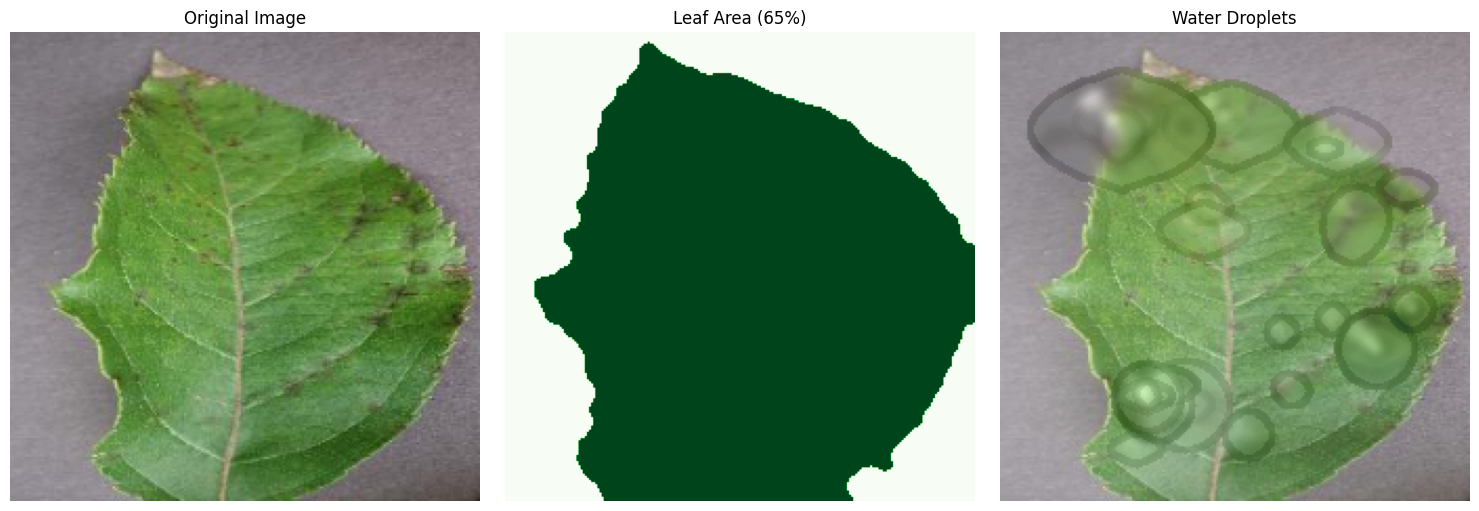

In [ ]:
#Select first image from dataset
sample_image = images[i+6]

#Detect leaf area
leaf_mask, ys, xs = get_leaf_mask(sample_image)

#Apply water droplet augmentation
droplet_image = add_realistic_water_droplets(sample_image)

#Create figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

#Original image
axes[0].imshow(sample_image)
axes[0].set_title("Original Image")
axes[0].axis("off")

#Leaf mask
axes[1].imshow(leaf_mask, cmap="Greens")

coverage = (len(xs) / (sample_image.shape[0] * sample_image.shape[1])) * 100

axes[1].set_title(f"Leaf Area ({coverage:.0f}%)")
axes[1].axis("off")

#Augmented image
axes[2].imshow(droplet_image)
axes[2].set_title("Water Droplets")
axes[2].axis("off")

plt.tight_layout()
plt.show()

A visual validation step was performed by displaying the original image, detected leaf mask, and augmented image to verify that realistic synthetic water droplets were placed only within the detected leaf region.

Multiple augmented versions of the same leaf image were generated using random droplet properties and fog intensity to demonstrate the variability and diversity introduced by the synthetic water droplet augmentation process.

## 8 - Generate the Full Droplet Dataset

In [ ]:
#Create augmented images for the entire dataset

print("Generating water droplet dataset...")

augmented_images = []

#Apply augmentation to every image
for image in images:

    droplet_image_1 = add_realistic_water_droplets(image)

    #Store augmented image
    augmented_images.append(droplet_image_1)

#Convert list to NumPy array
augmented_images = np.array(augmented_images, dtype=np.uint8)

#Print dataset information
print("Augmentation completed")
print("Images Shape :", augmented_images.shape)
print("Labels Shape :", labels.shape)

Generating water droplet dataset...
Augmentation completed
Images Shape : (54305, 224, 224, 3)
Labels Shape : (54305,)


Realistic water droplet augmentation was applied to every image in the dataset using random droplet properties and optional fog effects, generating a diverse set of environmentally distorted leaf images for robust crop disease classification.

## 9 - Save the Droplet Dataset


In [ ]:
#Save droplet dataset
np.save(
    f"{PROJECT_PATH}/droplet_images_2.npy",
    augmented_images
)
#Save labels separately
np.save(
    f"{PROJECT_PATH}/droplet_labels_2.npy",
    labels
)
print("Droplet dataset saved successfully")

Droplet dataset saved successfully


The augmented dataset containing synthetic water droplet images and their corresponding labels was saved in compressed NPZ format and verified by checking its dimensions and data type to ensure successful storage and future accessibility for model training.

## 10 - Side-by-Side Grid

In [22]:
augmented_images = np.load(f"{PROJECT_PATH}/droplet_images_2.npy")

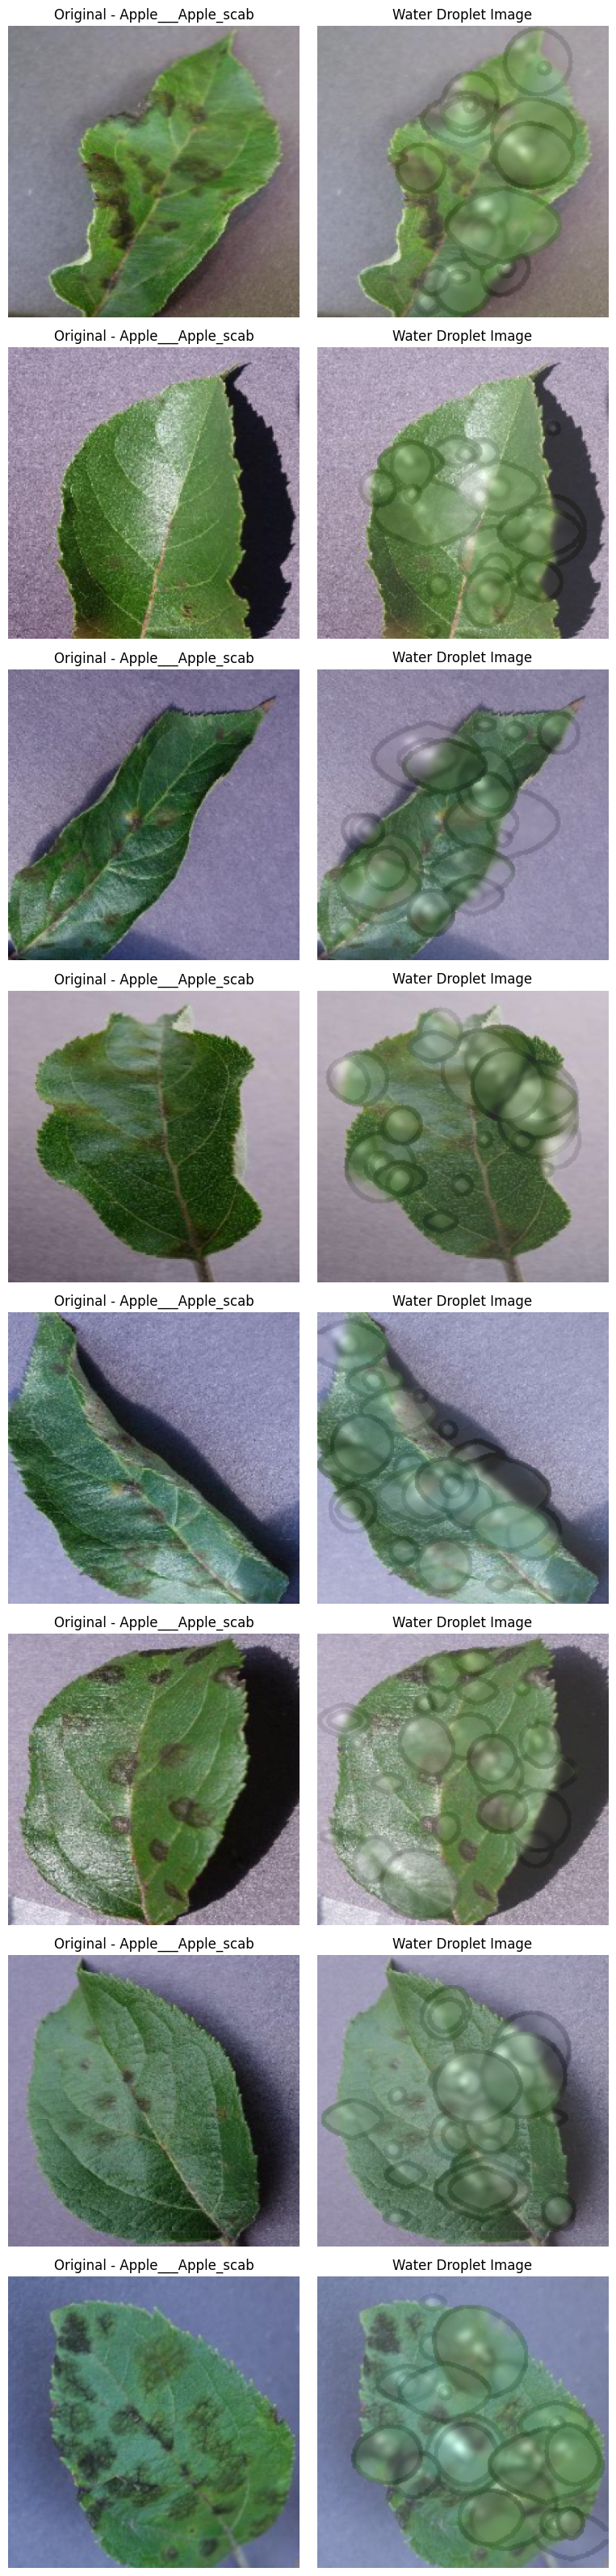

In [ ]:
#Compare original and augmented images

fig, axes = plt.subplots(8, 2, figsize=(8, 32))

#Select 8 random images
sample_indices = random.sample(
    range(len(images[i])),
    8
)
for row, idx in enumerate(sample_indices):

    #Original image
    axes[row, 0].imshow(images[idx])
    axes[row, 0].set_title(f"Original - {labels[idx]}")
    axes[row, 0].axis("off")

    #Augmented image
    axes[row, 1].imshow(augmented_images[idx])
    axes[row, 1].set_title("Water Droplet Image")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

A final quality assessment was performed by visually comparing randomly selected original and water droplet augmented images to verify the realism of the augmentation process and ensure that disease characteristics remained clearly visible for model training.

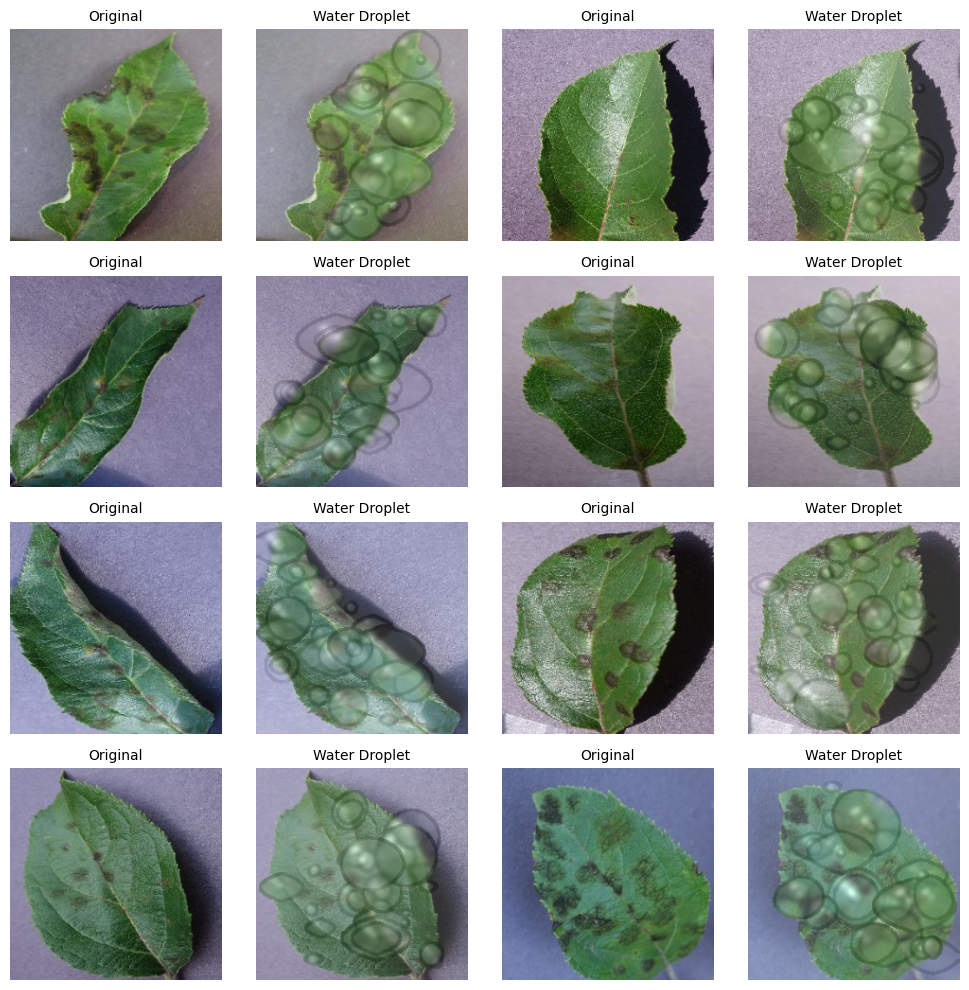

In [ ]:
#Create a 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for i, idx in enumerate(sample_indices):

    #Determine row and starting column for each pair
    row = i // 2
    col = (i % 2) * 2

    #Original image
    axes[row, col].imshow(images[idx])
    axes[row, col].set_title("Original", fontsize=10)
    axes[row, col].axis("off")

    #Water Droplet image
    axes[row, col + 1].imshow(augmented_images[idx])
    axes[row, col + 1].set_title("Water Droplet", fontsize=10)
    axes[row, col + 1].axis("off")

plt.tight_layout()

#Save the figure
plt.savefig(
    f"{PROJECT_PATH}/graphs/final_quality_check_4x4.png", dpi=300, bbox_inches="tight")

plt.show()